In [2]:
ab_test <- read.csv("../dataset/cleaned/ab_test_clean.csv")
head(ab_test)

,id,time,con_treat,page,converted
,<int>,<chr>,<chr>,<chr>,<int>
1,851104,11:48.6,control,old_page,0
2,804228,01:45.2,control,old_page,0
3,661590,55:06.2,treatment,new_page,0
4,853541,28:03.1,treatment,new_page,0
5,864975,52:26.2,control,old_page,1
6,936923,20:49.1,control,old_page,0


In [3]:
countries_ab <- read.csv("../dataset/raw/countries_ab.csv")
head(countries_ab)

,id,country
,<int>,<chr>
1,834778,UK
2,928468,US
3,822059,UK
4,711597,UK
5,710616,UK
6,909908,UK


In [4]:
tibble::glimpse(ab_test)

Rows: 290,584
Columns: 5
$ id        <int> 851104, 804228, 661590, 853541, 864975, 936923, 679687, 7190…
$ time      <chr> "11:48.6", "01:45.2", "55:06.2", "28:03.1", "52:26.2", "20:4…
$ con_treat <chr> "control", "control", "treatment", "treatment", "control", "…
$ page      <chr> "old_page", "old_page", "new_page", "new_page", "old_page", …
$ converted <int> 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, …


In [5]:
tibble::glimpse(countries_ab)

Rows: 290,584
Columns: 2
$ id      <int> 834778, 928468, 822059, 711597, 710616, 909908, 811617, 938122…
$ country <chr> "UK", "US", "UK", "UK", "UK", "UK", "US", "US", "US", "US", "U…


In [6]:
library(dplyr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [7]:
ab_full <- ab_test %>% inner_join(countries_ab, by = 'id')

In [8]:
tibble::glimpse(ab_full)

Rows: 290,584
Columns: 6
$ id        <int> 851104, 804228, 661590, 853541, 864975, 936923, 679687, 7190…
$ time      <chr> "11:48.6", "01:45.2", "55:06.2", "28:03.1", "52:26.2", "20:4…
$ con_treat <chr> "control", "control", "treatment", "treatment", "control", "…
$ page      <chr> "old_page", "old_page", "new_page", "new_page", "old_page", …
$ converted <int> 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, …
$ country   <chr> "US", "US", "US", "US", "US", "US", "CA", "US", "UK", "CA", …


In [9]:
nrow(anti_join(ab_test, countries_ab, by = "id"))

[1] 0

In [10]:
countries_ab %>% count(id) %>% filter(n > 1)

id,n
<int>,<int>


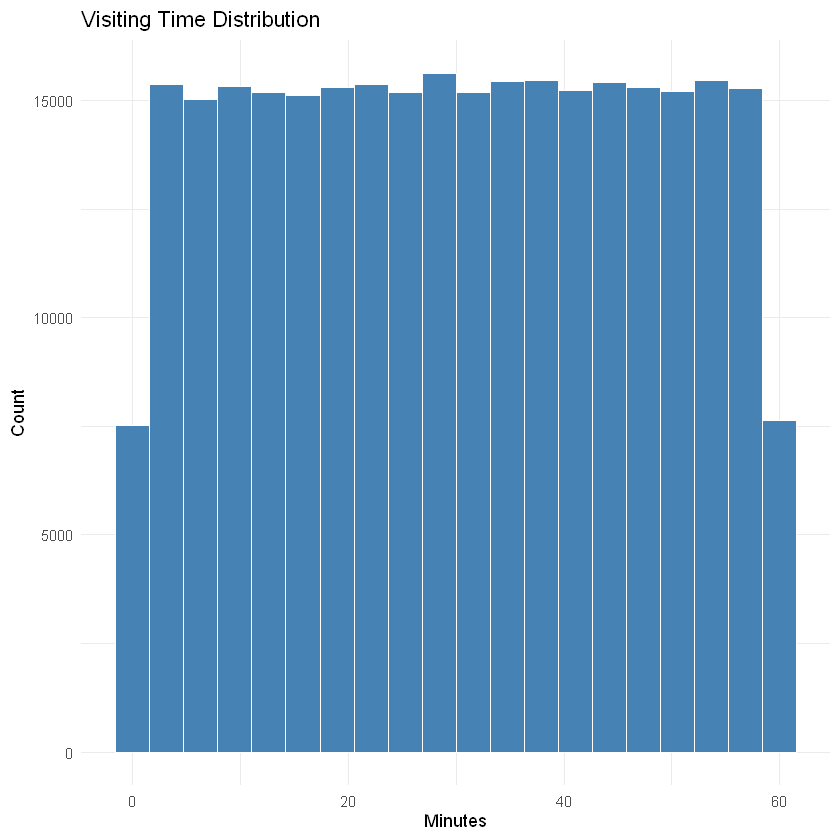

In [11]:
library(ggplot2)

ab_full <- ab_full %>%
  mutate(
    time_min = as.numeric(sub(":.*$", "", time)),
    time_sec = as.numeric(sub("^.*:", "", time)),
    time_num_min = time_min + time_sec/60
  )

ggplot(ab_full, aes(x = time_num_min)) +
  geom_histogram(bins = 20, fill = "steelblue", color = "white") +
  labs(
    title = "Visiting Time Distribution",
    x = "Minutes",
    y = "Count"
  ) +
  theme_minimal()

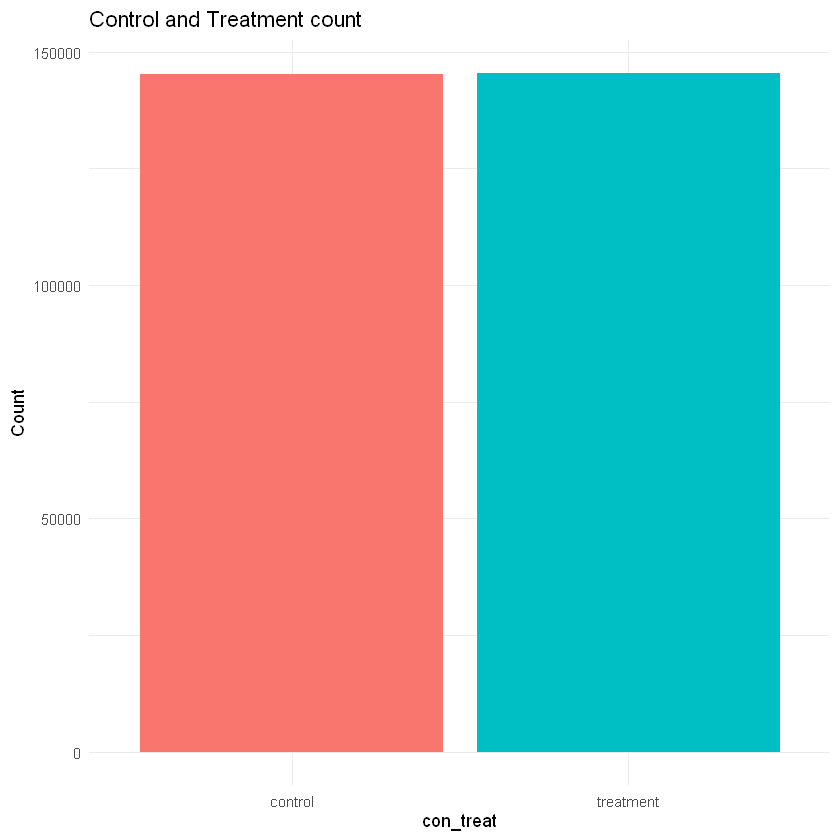

In [12]:
ab_full %>%
    count(con_treat) %>%
    ggplot(aes(x = con_treat, y = n, fill = con_treat)) +
    geom_col() +
    labs(title = "Control and Treatment count", x = "con_treat", y = "Count") +
    theme_minimal() +
    theme(legend.position = "none")

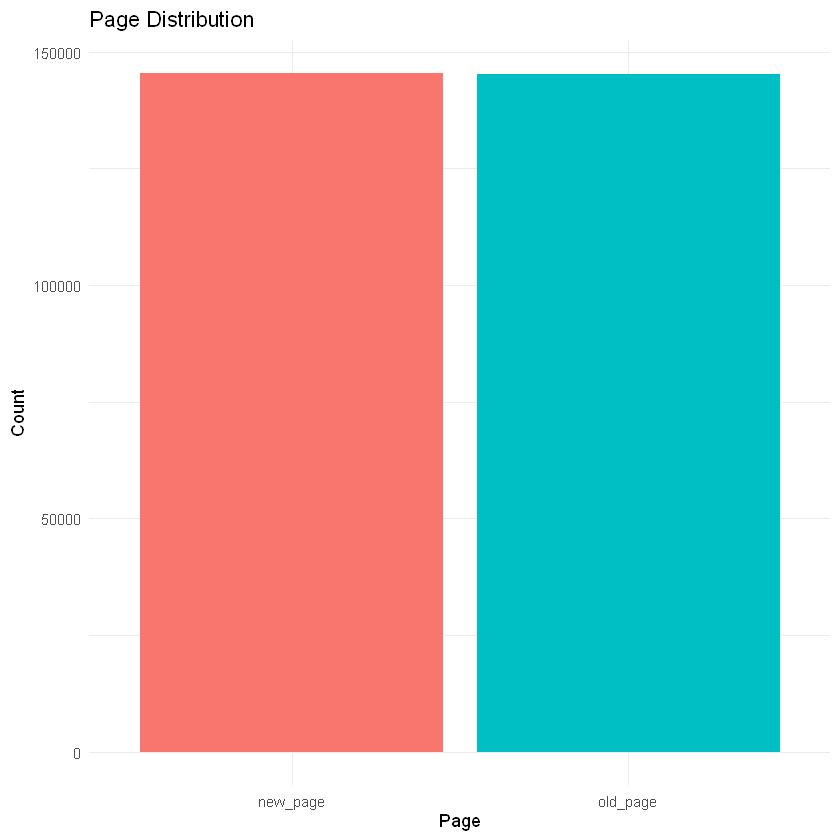

In [13]:
ab_full %>%
    count(page) %>%
    ggplot(aes(x = page, y = n, fill = page)) +
    geom_col() +
    labs(title = "Page Distribution", x = "Page", y = "Count") +
    theme_minimal() +
    theme(legend.position = "none")

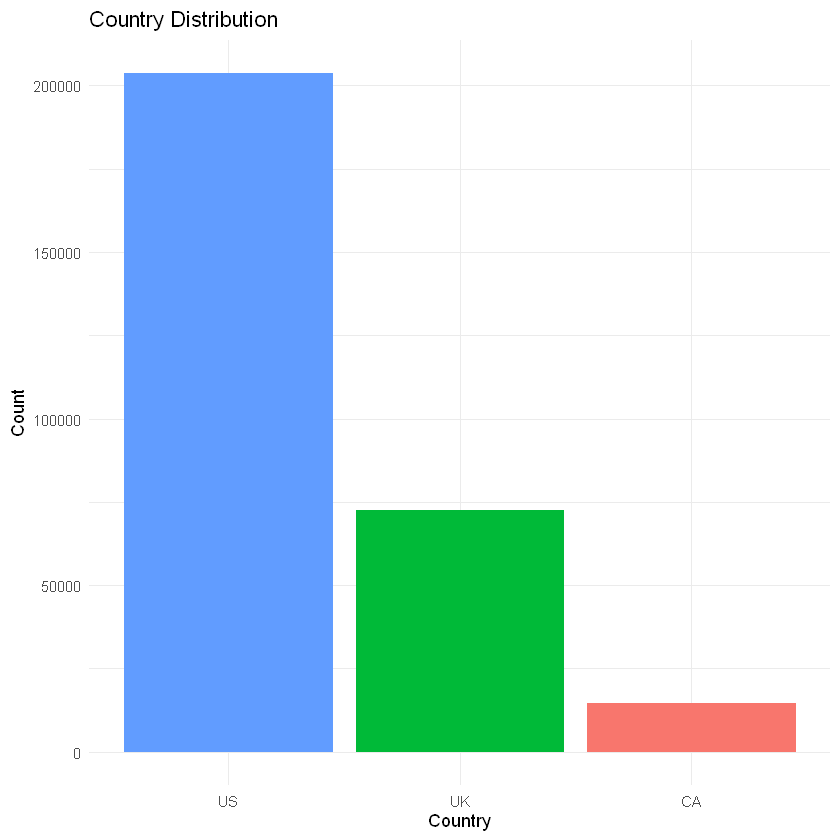

In [14]:
ab_full %>%
    count(country) %>%
    ggplot(aes(x = reorder(country, -n), y = n, fill = country)) +
    geom_col() +
    labs(title = "Country Distribution", x = "Country", y = "Count") +
    theme_minimal() +
    theme(legend.position = "none")

In [15]:
ab_viz <- ab_full %>%
    mutate(
        converted = factor(converted, levels = c(0, 1), labels = c("No", "Yes"))
    )

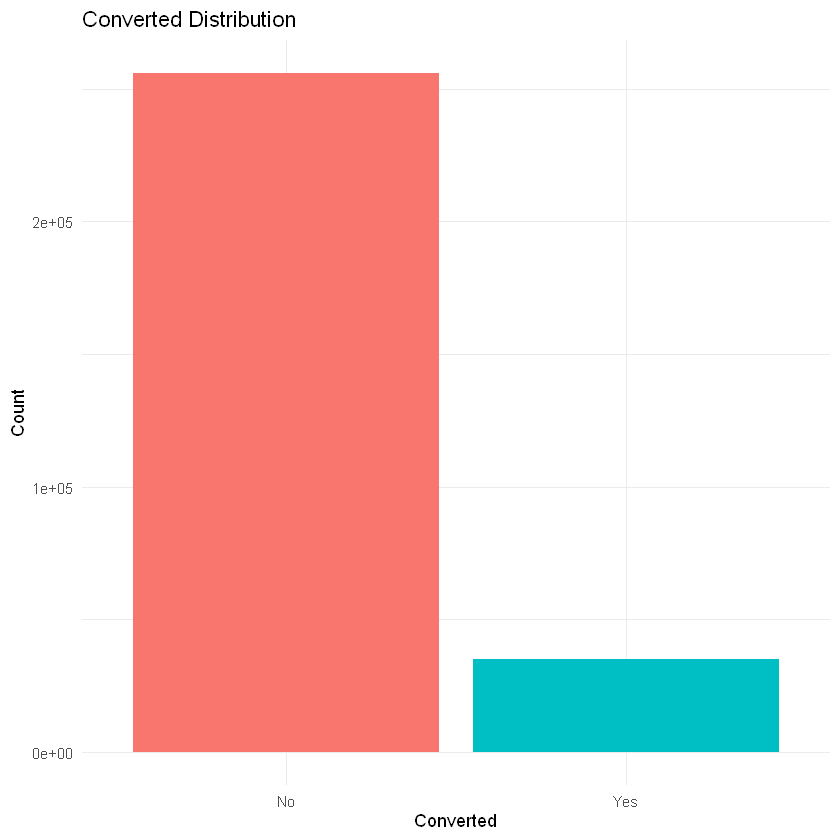

In [16]:
ab_viz %>%
    count(converted) %>%
    ggplot(aes(x = converted, y = n, fill = converted)) +
    geom_col() +
    labs(title = "Converted Distribution", x = "Converted", y = "Count") +
    theme_minimal() +
    theme(legend.position = "none")

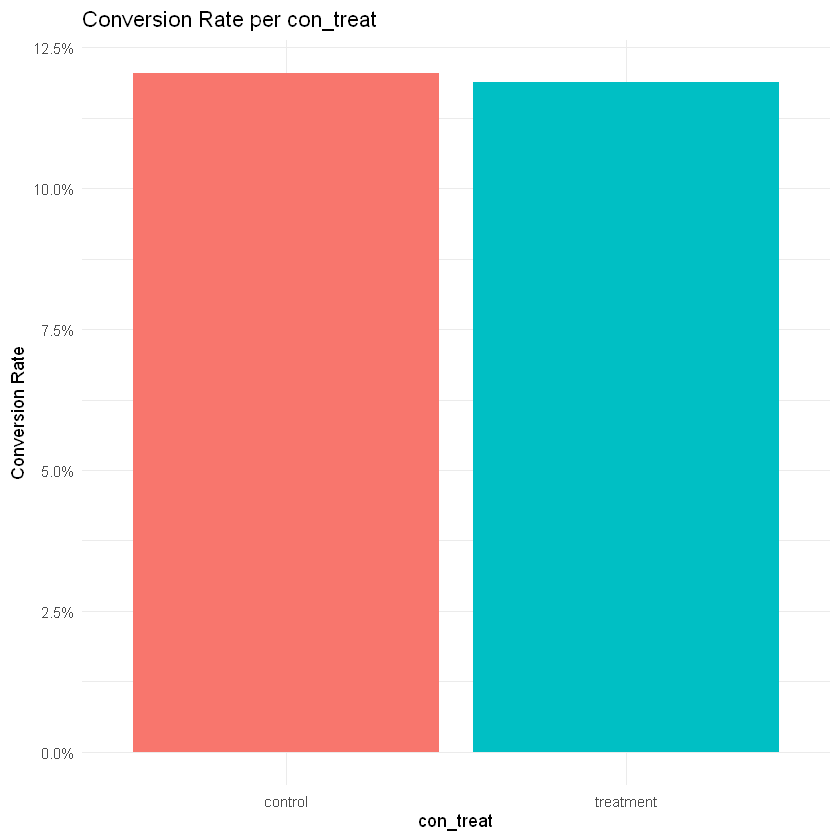

In [17]:
library(scales)

ab_viz %>%
    group_by(con_treat) %>%
    summarise(conv_rate = mean(converted == "Yes"), .groups = "drop") %>%
    ggplot(aes(x = con_treat, y = conv_rate, fill = con_treat)) +
    geom_col() +
    scale_y_continuous(labels = percent_format()) +
    labs(title = "Conversion Rate per con_treat", x = "con_treat", y = "Conversion Rate") +
    theme_minimal() +
    theme(legend.position = "none")

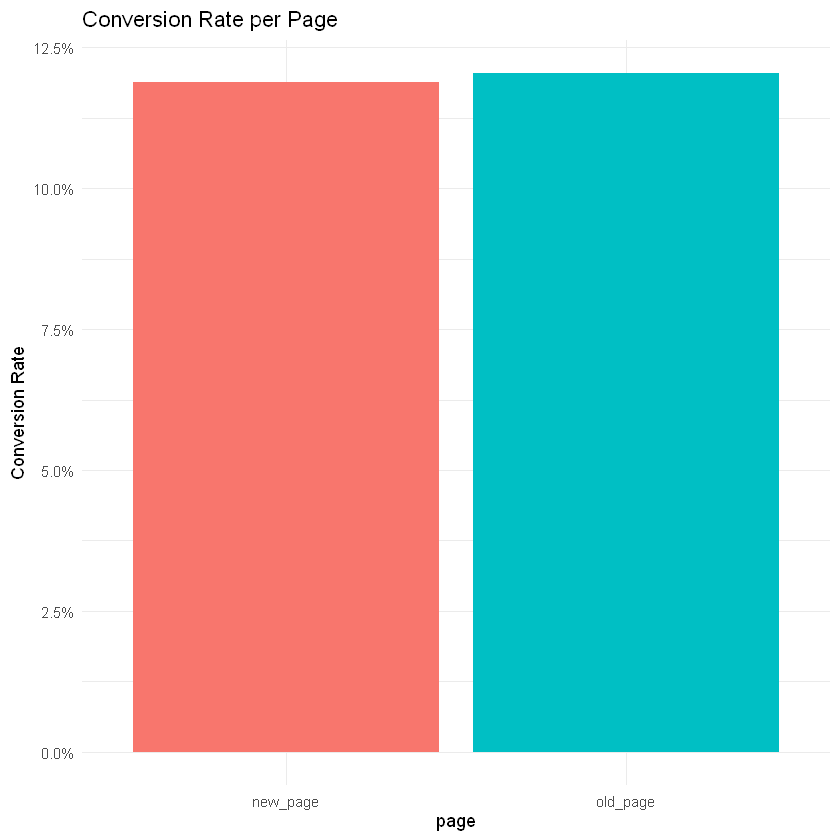

In [18]:
ab_viz %>%
    group_by(page) %>%
    summarise(conv_rate = mean(converted == "Yes"), .groups = "drop") %>%
    ggplot(aes(x = page, y = conv_rate, fill = page)) +
    geom_col() +
    scale_y_continuous(labels = percent_format()) +
    labs(title = "Conversion Rate per Page", x = "page", y = "Conversion Rate") +
    theme_minimal() +
    theme(legend.position = "none")

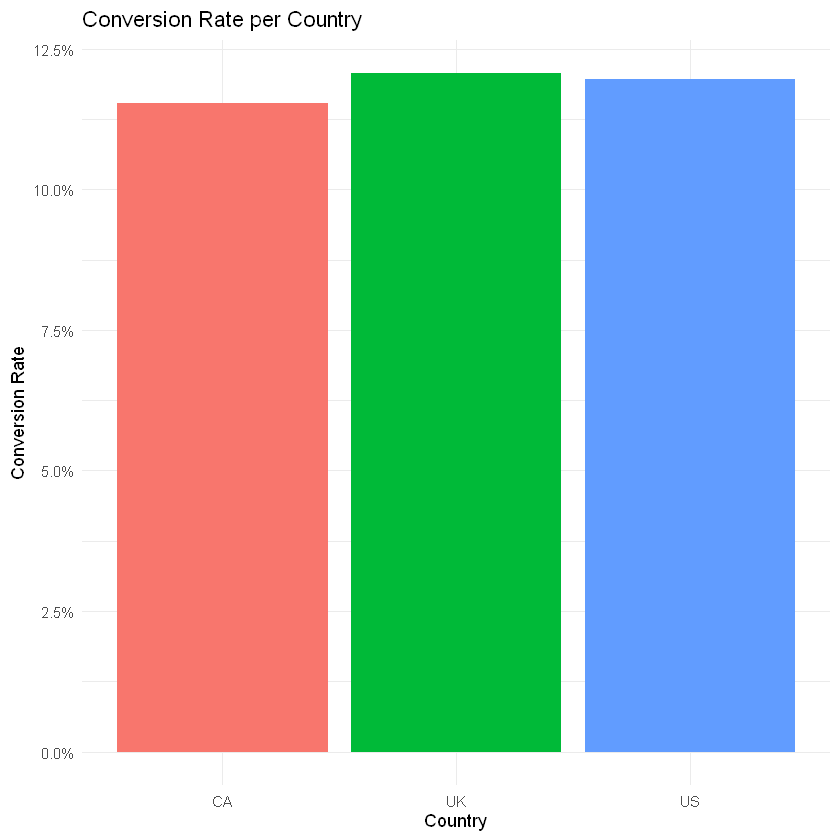

In [19]:
ab_viz %>%
    group_by(country) %>%
    summarise(conv_rate = mean(converted == "Yes"), .groups = "drop") %>%
    ggplot(aes(x = country, y = conv_rate, fill = country)) +
    geom_col() +
    scale_y_continuous(labels = percent_format()) +
    labs(title = "Conversion Rate per Country", x = "Country", y = "Conversion Rate") +
    theme_minimal() +
    theme(legend.position = "none")

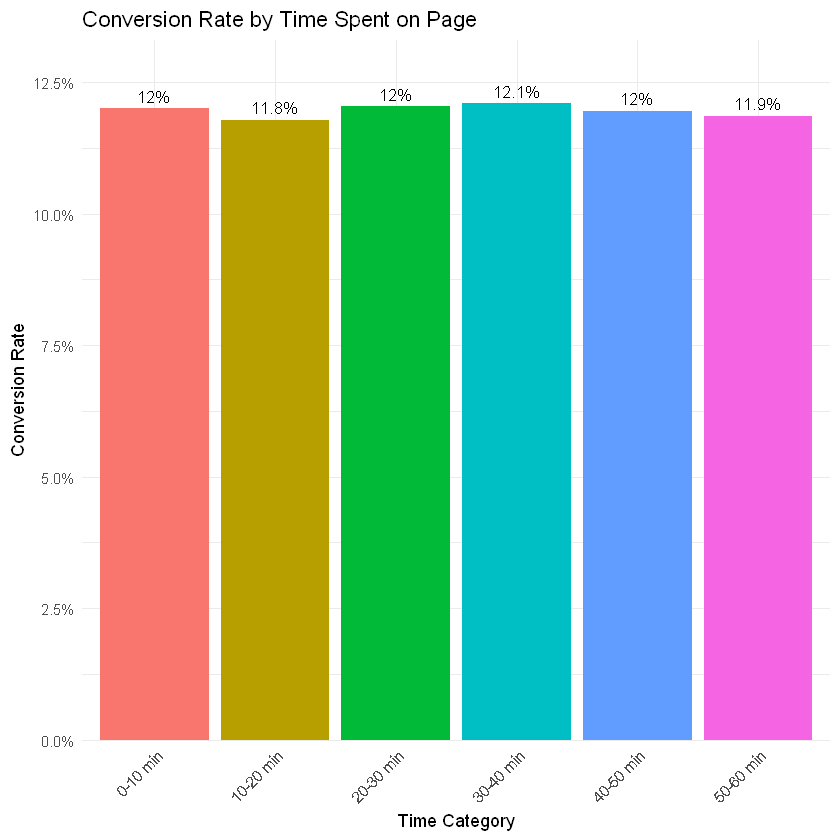

In [23]:
ab_viz %>%
    mutate(
        converted_num = ifelse(converted == "Yes", 1, 0),
        time_category = cut(time_num_min,
                            breaks = seq(0, max(time_num_min, na.rm = TRUE) + 10, by = 10),
                            labels = paste0(seq(0, max(time_num_min, na.rm = TRUE), by = 10) %>% round(), 
                                           "-", 
                                           seq(10, max(time_num_min, na.rm = TRUE) + 10, by = 10) %>% round(),
                                           " min"),
                            include.lowest = TRUE,
                            right = FALSE)
    ) %>%
    group_by(time_category) %>%
    summarise(
        conv_rate = mean(converted_num, na.rm = TRUE),
        n = n(),
        .groups = "drop"
    ) %>%
    ggplot(aes(x = time_category, y = conv_rate, fill = time_category)) +
    geom_col() +
    geom_text(aes(label = paste0(round(conv_rate * 100, 1), "%")), 
              vjust = -0.5, size = 3.5) +
    scale_y_continuous(labels = percent_format(), expand = expansion(mult = c(0, 0.1))) +
    labs(
        title = "Conversion Rate by Time Spent on Page",
        x = "Time Category",
        y = "Conversion Rate"
    ) +
    theme_minimal() +
    theme(
        legend.position = "none",
        axis.text.x = element_text(angle = 45, hjust = 1)
    )

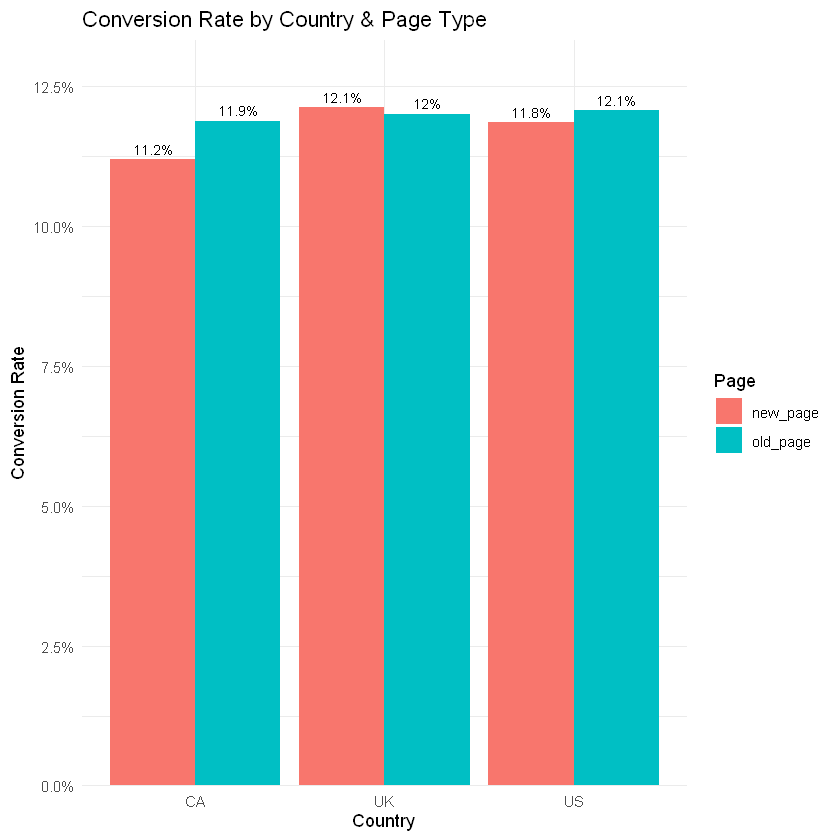

In [24]:
ab_viz %>%
    group_by(country, page) %>%
    summarise(conv_rate = mean(converted == "Yes"), .groups = "drop") %>%
    ggplot(aes(x = country, y = conv_rate, fill = page)) +
    geom_col(position = "dodge") +
    geom_text(aes(label = paste0(round(conv_rate * 100, 1), "%")),
              position = position_dodge(width = 0.9),
              vjust = -0.5, size = 3) +
    scale_y_continuous(labels = percent_format(), expand = expansion(mult = c(0, 0.1))) +
    labs(
        title = "Conversion Rate by Country & Page Type",
        x = "Country", y = "Conversion Rate", fill = "Page"
    ) +
    theme_minimal()

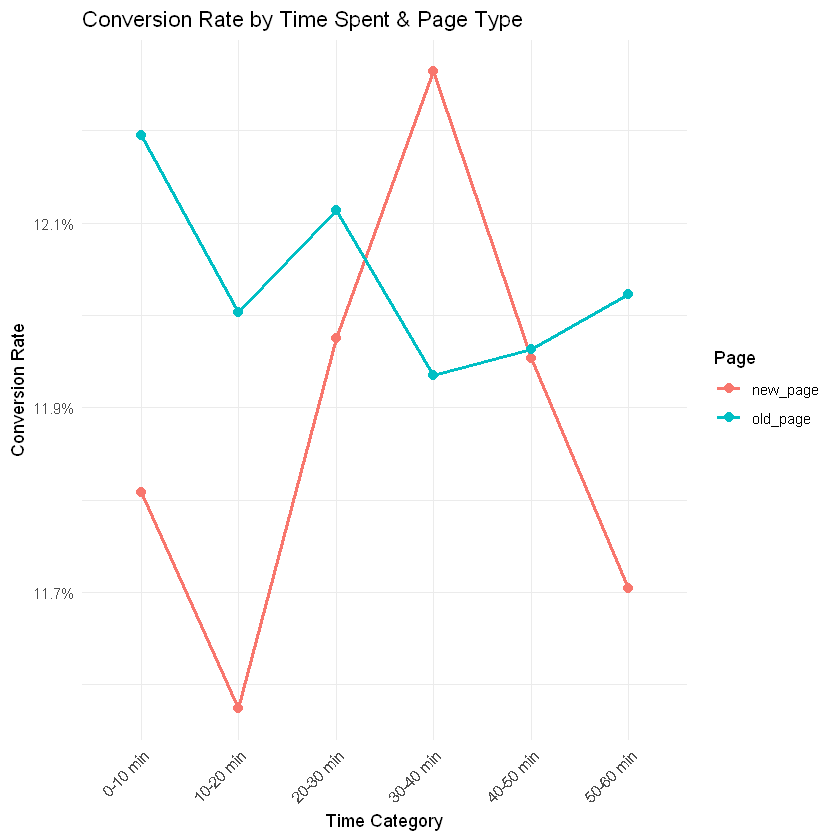

In [25]:
ab_viz %>%
    mutate(
        converted_num = ifelse(converted == "Yes", 1, 0),
        time_category = cut(time_num_min,
                            breaks = seq(0, max(time_num_min, na.rm = TRUE) + 10, by = 10),
                            labels = paste0(seq(0, max(time_num_min, na.rm = TRUE), by = 10) %>% round(),
                                           "-",
                                           seq(10, max(time_num_min, na.rm = TRUE) + 10, by = 10) %>% round(),
                                           " min"),
                            include.lowest = TRUE, right = FALSE)
    ) %>%
    group_by(time_category, page) %>%
    summarise(conv_rate = mean(converted_num, na.rm = TRUE), .groups = "drop") %>%
    ggplot(aes(x = time_category, y = conv_rate, color = page, group = page)) +
    geom_line(linewidth = 1) +
    geom_point(size = 2.5) +
    scale_y_continuous(labels = percent_format()) +
    labs(
        title = "Conversion Rate by Time Spent & Page Type",
        x = "Time Category", y = "Conversion Rate", color = "Page"
    ) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [27]:
library(dplyr)

conv_summary <- ab_viz %>%
    group_by(page) %>%
    summarise(
        n_users     = n(),
        n_converted = sum(converted == "Yes"),
        conv_rate   = n_converted / n_users,
        .groups = "drop"
    )

print(conv_summary)

# A tibble: 2 × 4
  page     n_users n_converted conv_rate
  <chr>      <int>       <int>     <dbl>
1 new_page  145310       17264     0.119
2 old_page  145274       17489     0.120


In [ ]:
n_new     <- conv_summary %>% filter(page == "new_page") %>% pull(n_users)
n_old     <- conv_summary %>% filter(page == "old_page") %>% pull(n_users)
conv_new  <- conv_summary %>% filter(page == "new_page") %>% pull(n_converted)
conv_old  <- conv_summary %>% filter(page == "old_page") %>% pull(n_converted)

result <- prop.test(
    x = c(conv_new, conv_old),   
    n = c(n_new, n_old),         
    alternative = "two.sided",   
    conf.level = 0.95,
    correct = FALSE              
)

print(result)


	2-sample test for equality of proportions without continuity correction

data:  c(conv_new, conv_old) out of c(n_new, n_old)
X-squared = 1.7185, df = 1, p-value = 0.1899
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.0039378602  0.0007813823
sample estimates:
   prop 1    prop 2 
0.1188081 0.1203863 

